In [1]:
import os, math, random, gc, shutil, sys
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.serialization
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

In [2]:
torch.serialization.add_safe_globals([np._core.multiarray.scalar])

In [3]:
DATASET_DIR  = '/kaggle/input/datasets/almiraraisa/aptos-2019-rev'
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
NUM_CLASSES  = len(CLASS_NAMES)
BATCH_SIZE   = 32
NUM_EPOCHS   = 100
LR           = 1e-3
WEIGHT_DECAY = 1e-4
SEEDS        = [33, 81, 5]
CKPT_DIR     = '/kaggle/working/'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Device: {device}")

Device: cuda


In [4]:
def set_seed(seed=30):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

In [5]:
# checkpoints

def save_resume_ckpt(path, epoch, model, optimizer, scheduler, scaler,
                     history, best_qwk, best_preds, best_labels):
    torch.save({
        'epoch':            epoch,
        'model_state_dict': model.state_dict(),
        'optimizer':        optimizer.state_dict(),
        'scheduler':        scheduler.state_dict(),
        'scaler':           scaler.state_dict(),
        'history':          history,
        'best_qwk':         best_qwk,
        'best_preds':       best_preds,
        'best_labels':      best_labels,
    }, path)

def load_resume_ckpt(path, model, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    scaler.load_state_dict(ckpt['scaler'])
    print(f"  ↺ Resumed from epoch {ckpt['epoch']+1}  "
          f"(best QWK so far: {ckpt['best_qwk']:.4f})")
    return (ckpt['epoch'] + 1, ckpt['history'],
            ckpt['best_qwk'], ckpt['best_preds'], ckpt['best_labels'])

def save_best_weights(path, epoch, model, qwk):
    torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'qwk': qwk}, path)

def _recompute_no_improve(history):
    if not history['val_qwk']:
        return 0
    peak          = max(history['val_qwk'])
    last_peak_idx = max(i for i, v in enumerate(history['val_qwk']) if v == peak)
    return len(history['val_qwk']) - 1 - last_peak_idx

In [6]:
class AptosDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img_col = 'id_code' if 'id_code' in self.df.columns else self.df.columns[0]
        fname   = str(row[img_col])
        fname   = fname if fname.endswith('.png') else fname + '.png'
        img     = Image.open(self.image_dir / fname).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['diagnosis']), dtype=torch.long)

In [7]:
train_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_df = pd.read_csv(f'{DATASET_DIR}/train_split.csv')
val_df   = pd.read_csv(f'{DATASET_DIR}/val_split.csv')
test_df  = pd.read_csv(f'{DATASET_DIR}/test_split.csv')

train_df['diagnosis'] = train_df['diagnosis'].astype(int)

class_counts   = train_df['diagnosis'].value_counts().sort_index().values
sample_weights = train_df['diagnosis'].map(lambda x: 1.0 / class_counts[int(x)]).values
sampler = WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.float),
                                len(sample_weights), replacement=True)

train_loader = DataLoader(AptosDataset(train_df, f'{DATASET_DIR}/images', train_tfm),
                          batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(AptosDataset(val_df,   f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(AptosDataset(test_df,  f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

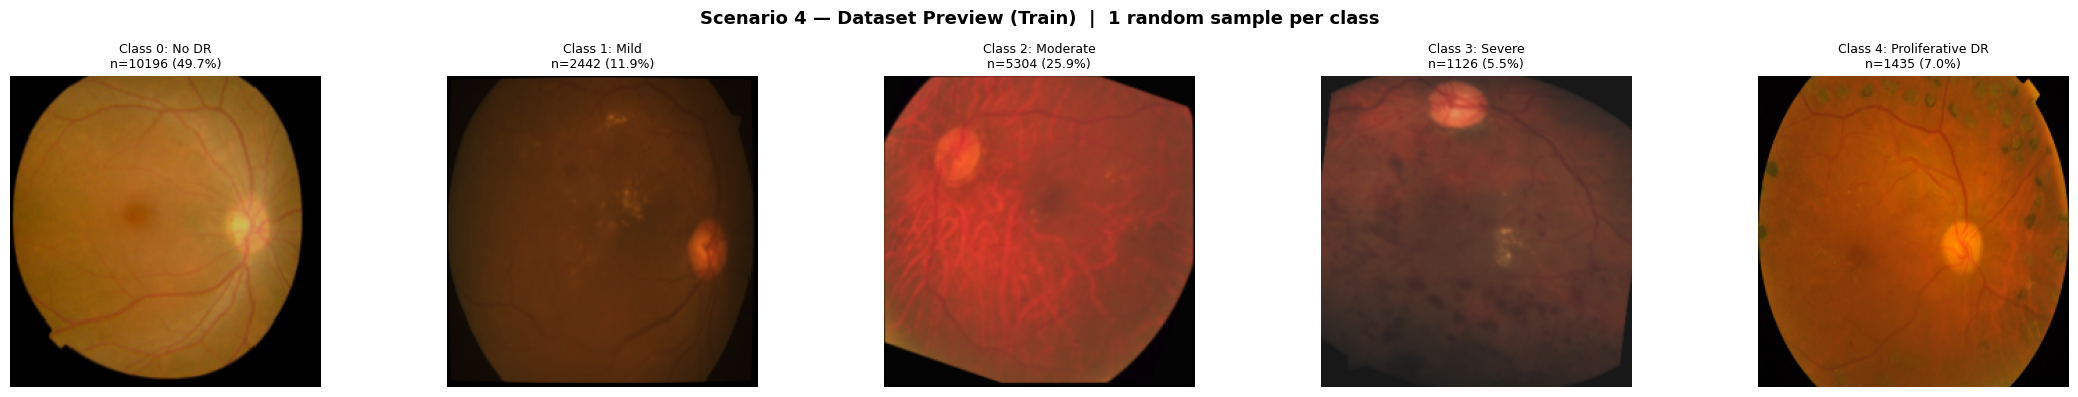


── Dataset Statistics ──────────────────────────────────
  Train: 20503 | Val: 366 | Test: 367
  Class distribution (train):
  [0] No DR               : 10196 ( 49.7%)  ██████████████
  [1] Mild                : 2442 ( 11.9%)  ███
  [2] Moderate            : 5304 ( 25.9%)  ███████
  [3] Severe              : 1126 (  5.5%)  █
  [4] Proliferative DR    : 1435 (  7.0%)  ██


In [8]:
def preview_dataset(df, image_dir, split_name="Train"):
    image_dir = Path(image_dir)
    img_col   = 'id_code' if 'id_code' in df.columns else df.columns[0]
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
    fig.suptitle(f"Scenario 4 — Dataset Preview ({split_name})  |  1 random sample per class",
                 fontsize=13, fontweight='bold')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        subset = df[df['diagnosis'] == cls_idx]
        row    = subset.sample(1, random_state=42).iloc[0]
        fname  = str(row[img_col]); fname = fname if fname.endswith('.png') else fname + '.png'
        img    = Image.open(image_dir / fname).convert('RGB')
        axes[cls_idx].imshow(img)
        axes[cls_idx].set_title(
            f"Class {cls_idx}: {cls_name}\nn={len(subset)} ({100*len(subset)/len(df):.1f}%)",
            fontsize=9)
        axes[cls_idx].axis('off')
    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("\n── Dataset Statistics ──────────────────────────────────")
    print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print("  Class distribution (train):")
    for i, name in enumerate(CLASS_NAMES):
        n   = (train_df['diagnosis'] == i).sum()
        bar = '█' * int(30 * n / len(train_df))
        print(f"  [{i}] {name:<20s}: {n:4d} ({100*n/len(train_df):5.1f}%)  {bar}")

preview_dataset(train_df, f'{DATASET_DIR}/images')

In [9]:
def analyse_results(results_list, scenario_title, loss_label="Loss", teacher_accs=None, test_results_list=None):
    import matplotlib.ticker as mticker
    from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

    seeds      = [r['seed'] for r in results_list]
    all_losses = np.array([r['history']['train_loss'] for r in results_list])
    all_qwks   = np.array([r['history']['val_qwk']    for r in results_list])
    all_accs   = np.array([r['history']['val_acc']    for r in results_list])
    all_maes   = np.array([r['history']['val_mae']    for r in results_list], dtype=float)
    epochs     = np.arange(1, all_losses.shape[1] + 1)
    best_res   = max(results_list, key=lambda x: x['qwk'])
    colors     = plt.cm.tab10.colors

    cms         = [confusion_matrix(r['labels'], r['preds'], labels=list(range(NUM_CLASSES)))
                   for r in results_list]
    cm_avg      = np.mean(cms, axis=0)
    cm_std      = np.std(cms,  axis=0)
    cm_avg_norm = cm_avg / cm_avg.sum(axis=1, keepdims=True)
    cm_best     = confusion_matrix(best_res['labels'], best_res['preds'],
                                   labels=list(range(NUM_CLASSES)))

    seed_accs = [np.mean(np.array(r['labels']) == np.array(r['preds'])) * 100
                 for r in results_list]
    seed_maes = [np.mean(np.abs(np.array(r['labels']) - np.array(r['preds'])))
                 for r in results_list]
    mean_acc  = np.mean(seed_accs);  std_acc  = np.std(seed_accs)
    mean_qwk  = np.mean([r['qwk'] for r in results_list])
    std_qwk   = np.std([r['qwk']  for r in results_list])
    mean_mae  = np.mean(seed_maes);  std_mae  = np.std(seed_maes)

    per_cls_acc = cm_avg.diagonal() / cm_avg.sum(axis=1)

    misclass = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm_avg[i, j] > 0:
                misclass.append((cm_avg[i, j], i, j))
    misclass.sort(reverse=True)

    report    = classification_report(best_res['labels'], best_res['preds'],
                                      target_names=CLASS_NAMES, output_dict=True)
    best_acc  = np.mean(np.array(best_res['labels']) == np.array(best_res['preds'])) * 100
    CKPT_SAFE = (scenario_title.replace(' ', '_').replace('/', '_')
                               .replace('(', '').replace(')', ''))

    fig1 = plt.figure(figsize=(24, 20))
    fig1.suptitle(f"{scenario_title}\n— Training Analysis Dashboard —",
                  fontsize=16, fontweight='bold', y=0.99)
    gs1 = gridspec.GridSpec(4, 4, figure=fig1, hspace=0.42, wspace=0.30)

    ax = fig1.add_subplot(gs1[0, 0])
    bp = ax.boxplot([seed_accs], patch_artist=True, widths=0.4,
                    medianprops=dict(color='red', lw=2))
    bp['boxes'][0].set_facecolor('#aec6e8')
    ax.scatter([1] * len(seed_accs), seed_accs, color='black', s=40, zorder=5)
    ax.set_xticks([1]); ax.set_xticklabels(['Student'])
    ax.set_title(f"Val Accuracy Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(True, axis='y', ls='--', alpha=0.5)
    ax.text(1, mean_acc, f"μ={mean_acc:.2f}%\nσ={std_acc:.2f}%",
            ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    ax = fig1.add_subplot(gs1[0, 1])
    if teacher_accs:
        names      = [f"Teacher {i+1}" for i in range(len(teacher_accs))] + ['Student']
        values     = list(teacher_accs) + [mean_acc]
        bar_colors = ['#4878CF'] * len(teacher_accs) + ['#F8A60B']
        bars = ax.bar(range(len(names)), values, color=bar_colors,
                      width=0.5, edgecolor='white', lw=1.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{val:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
        ax.set_ylim(min(values) - 5, 100)
        ax.set_title("Teacher vs Student Accuracy", fontsize=11, fontweight='bold')
        ax.set_ylabel("Accuracy (%)")
    else:
        seed_qwks = [r['qwk'] for r in results_list]
        bp2 = ax.boxplot([seed_qwks], patch_artist=True, widths=0.4,
                         medianprops=dict(color='red', lw=2))
        bp2['boxes'][0].set_facecolor('#b8d4a8')
        ax.scatter([1] * len(seed_qwks), seed_qwks, color='black', s=40, zorder=5)
        ax.set_xticks([1]); ax.set_xticklabels(['Student'])
        ax.set_title(f"Val QWK Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Quadratic Weighted Kappa")
        ax.text(1, mean_qwk, f"μ={mean_qwk:.4f}\nσ={std_qwk:.4f}",
                ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[0, 2])
    bp3 = ax.boxplot([seed_maes], patch_artist=True, widths=0.4,
                     medianprops=dict(color='red', lw=2))
    bp3['boxes'][0].set_facecolor('#f4c2c2')
    ax.scatter([1] * len(seed_maes), seed_maes, color='black', s=40, zorder=5)
    ax.set_xticks([1]); ax.set_xticklabels(['Student'])
    ax.set_title(f"Val MAE Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Mean Absolute Error")
    ax.grid(True, axis='y', ls='--', alpha=0.5)
    ax.text(1, mean_mae, f"μ={mean_mae:.4f}\nσ={std_mae:.4f}",
            ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    ax = fig1.add_subplot(gs1[0, 3])
    mean_l = all_losses.mean(0); std_l = all_losses.std(0)
    ax.plot(epochs, mean_l, color='blue', lw=2.0, label=loss_label)
    ax.fill_between(epochs, mean_l - std_l, mean_l + std_l, alpha=0.15, color='blue')
    ax.set_title("Training Loss (Averaged)", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss Value (Normalized)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[1, 0])
    mean_a = all_accs.mean(0) * 100; std_a = all_accs.std(0) * 100
    ax.plot(epochs, mean_a, color='#1f77b4', lw=2.2, label='Mean')
    ax.fill_between(epochs, mean_a - std_a, mean_a + std_a,
                    alpha=0.25, color='#1f77b4', label='±1 std')
    ax.set_title("Validation Accuracy Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[1, 1])
    mean_q = all_qwks.mean(0); std_q = all_qwks.std(0)
    ax.plot(epochs, mean_q, color='#2ca02c', lw=2.2, label='Mean')
    ax.fill_between(epochs, mean_q - std_q, mean_q + std_q,
                    alpha=0.25, color='#2ca02c', label='±1 std')
    ax.set_title("Validation QWK Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("QWK")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax    = fig1.add_subplot(gs1[1, 2])
    valid = ~np.isnan(all_maes).all(axis=0)
    mean_m = np.nanmean(all_maes, axis=0); std_m = np.nanstd(all_maes, axis=0)
    ax.plot(epochs[valid], mean_m[valid], color='#d62728', lw=2.2, label='Mean')
    ax.fill_between(epochs[valid], (mean_m - std_m)[valid], (mean_m + std_m)[valid],
                    alpha=0.25, color='#d62728', label='±1 std')
    ax.set_title("Validation MAE Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[1, 3])
    ratio = all_qwks.mean(0) / (all_losses.mean(0) + 1e-8)
    ax.plot(epochs, ratio, color='purple', lw=1.8)
    ax.set_title("QWK / Loss Ratio Over Training", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("QWK / Loss Ratio")
    ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[2, 0])
    for i, r in enumerate(results_list):
        ax.plot(epochs, [a * 100 for a in r['history']['val_acc']],
                color=colors[i], lw=1.5, alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs, mean_a, 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Run Validation Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[2, 1])
    for i, r in enumerate(results_list):
        maes_run = [m for m in r['history']['val_mae'] if m is not None]
        ep_run   = epochs[:len(maes_run)]
        ax.plot(ep_run, maes_run, color=colors[i], lw=1.5, alpha=0.8, label=f"Seed {r['seed']}")
    ax.plot(epochs[valid], mean_m[valid], 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Run MAE Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[2, 2])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Raw Counts)", fontsize=11, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=8,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    ax = fig1.add_subplot(gs1[2, 3])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Normalized)", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=7.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    ax = fig1.add_subplot(gs1[3, 0])
    bars = ax.bar(range(NUM_CLASSES), per_cls_acc * 100,
                  color='#aec6e8', edgecolor='grey', lw=0.8)
    for bar, val in zip(bars, per_cls_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class Accuracy\n(from Averaged CM)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    ax = fig1.add_subplot(gs1[3, 1])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix\nStandard Deviation", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center',
                    fontsize=7.5, color='black')

    ax = fig1.add_subplot(gs1[3, 2])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=11, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=8,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    ax = fig1.add_subplot(gs1[3, 3])
    f1_scores = [report[cls]['f1-score'] for cls in CLASS_NAMES]
    f1_bars   = ax.bar(range(NUM_CLASSES), [f * 100 for f in f1_scores],
                       color='#b8d4a8', edgecolor='grey', lw=0.8)
    for bar, val in zip(f1_bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class F1 Score\n(Best Seed)", fontsize=11, fontweight='bold')
    ax.set_ylabel("F1 Score (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    fig1.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    fig2 = plt.figure(figsize=(20, 20))
    fig2.suptitle(f"{scenario_title}\n— Detailed Confusion Matrix Analysis —",
                  fontsize=15, fontweight='bold', y=0.99)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.38, wspace=0.28,
                            height_ratios=[1, 1, 0.48])

    ax = fig2.add_subplot(gs2[0, 0])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Raw Counts)", fontsize=12, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=9,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    ax = fig2.add_subplot(gs2[0, 1])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=8.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    ax = fig2.add_subplot(gs2[1, 0])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix Standard Deviation", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center',
                    fontsize=8.5, color='black')

    ax = fig2.add_subplot(gs2[1, 1])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=12, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=9,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    ax_txt = fig2.add_subplot(gs2[2, :])
    ax_txt.axis('off')

    best_mae = np.mean(np.abs(np.array(best_res['labels']) - np.array(best_res['preds'])))
    lines = []
    lines.append("=" * 80)
    lines.append(f"  PERFORMANCE SUMMARY — {scenario_title}")
    lines.append("=" * 80)
    lines.append(f"  Seeds trained              : {seeds}")
    lines.append(f"  Val Accuracy  (mean ± std) : {mean_acc:.2f}%  ±  {std_acc:.2f}%"
                 f"  [range: {min(seed_accs):.2f}% – {max(seed_accs):.2f}%]")
    lines.append(f"  Val QWK       (mean ± std) : {mean_qwk:.4f}  ±  {std_qwk:.4f}"
                 f"  [range: {min(r['qwk'] for r in results_list):.4f} – "
                 f"{max(r['qwk'] for r in results_list):.4f}]")
    lines.append(f"  Val MAE       (mean ± std) : {mean_mae:.4f}  ±  {std_mae:.4f}"
                 f"  [range: {min(seed_maes):.4f} – {max(seed_maes):.4f}]")
    lines.append(f"  Best seed                  : Seed {best_res['seed']}"
                 f"  (QWK={best_res['qwk']:.4f}, Acc={best_acc:.2f}%, MAE={best_mae:.4f})")
    lines.append(f"  Final train loss (mean)    : {all_losses[:, -1].mean():.4f}"
                 f"  ±  {all_losses[:, -1].std():.4f}")
    lines.append(f"  Peak QWK epoch  (mean)     : "
                 f"{np.mean([np.argmax(r['history']['val_qwk'])+1 for r in results_list]):.1f}")
    lines.append(f"  Peak MAE epoch  (mean)     : "
                 f"{np.mean([int(np.nanargmin(r['history']['val_mae']))+1 for r in results_list]):.1f}")
    lines.append("")
    lines.append("  Per-class Performance (best seed):")
    lines.append(f"  {'Class':<20s}  {'Precision':>9s}  {'Recall':>9s}  "
                 f"{'F1-Score':>9s}  {'Support':>7s}")
    lines.append("  " + "-" * 60)
    for cls in CLASS_NAMES:
        d = report[cls]
        lines.append(f"  {cls:<20s}  {d['precision']:>9.3f}  {d['recall']:>9.3f}  "
                     f"{d['f1-score']:>9.3f}  {int(d['support']):>7d}")
    lines.append("  " + "-" * 60)
    lines.append(f"  {'Overall Accuracy':<20s}  {'—':>9s}  {'—':>9s}  "
                 f"{report['accuracy']:>9.3f}  {len(best_res['labels']):>7d}")
    lines.append(f"  {'Macro Avg F1':<20s}  {report['macro avg']['precision']:>9.3f}  "
                 f"{report['macro avg']['recall']:>9.3f}  "
                 f"{report['macro avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append(f"  {'Weighted Avg F1':<20s}  {report['weighted avg']['precision']:>9.3f}  "
                 f"{report['weighted avg']['recall']:>9.3f}  "
                 f"{report['weighted avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append("")
    lines.append("  Top-5 Most Common Misclassifications (averaged across seeds):")
    for rank, (count, true_c, pred_c) in enumerate(misclass[:5], 1):
        pct = count / cm_avg.sum(axis=1)[true_c] * 100
        lines.append(f"    {rank}. True={CLASS_NAMES[true_c]:<20s} → "
                     f"Predicted={CLASS_NAMES[pred_c]:<20s}"
                     f"  (avg count={count:.1f}, {pct:.1f}% of true class)")
    lines.append("")
    lines.append("  Class Performance Range (per-class accuracy from averaged CM):")
    cls_accs_sorted = sorted(zip(per_cls_acc, CLASS_NAMES), reverse=True)
    lines.append(f"    Best  : {cls_accs_sorted[0][1]}  ({cls_accs_sorted[0][0]*100:.1f}%)")
    lines.append(f"    Worst : {cls_accs_sorted[-1][1]}  ({cls_accs_sorted[-1][0]*100:.1f}%)")
    lines.append(f"    Range : {cls_accs_sorted[-1][0]*100:.1f}% – {cls_accs_sorted[0][0]*100:.1f}%"
                 f"  (gap = {(cls_accs_sorted[0][0]-cls_accs_sorted[-1][0])*100:.1f}pp)")
    lines.append("=" * 80)

    summary_text = '\n'.join(lines)
    ax_txt.text(0.01, 0.99, summary_text, transform=ax_txt.transAxes,
                fontsize=8.2, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.9, edgecolor='#dee2e6'))

    fig2.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_cm_detail.png', dpi=130, bbox_inches='tight')
    plt.show()

    print('\n'.join(lines))

In [10]:
class CoralHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc   = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1))

    def forward(self, x):
        return self.fc(x) + self.bias

def coral_loss(logits, labels, num_classes=NUM_CLASSES):
    targets = torch.zeros(labels.size(0), num_classes - 1, device=labels.device)
    for k in range(num_classes - 1):
        targets[:, k] = (labels > k).float()
    return F.binary_cross_entropy_with_logits(logits, targets)

def coral_predict(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1).long()

In [11]:
TEMPERATURE = 6.0
ALPHA = 0.9

def get_resnet50_teacher():
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    in_features = m.fc.in_features
    m.fc = nn.Identity()
    m.coral_head = CoralHead(in_features, NUM_CLASSES)
    return m

def get_efficientnet_b3_teacher():
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    in_features = m.classifier[-1].in_features
    m.classifier[-1] = nn.Identity()
    m.coral_head = CoralHead(in_features, NUM_CLASSES)
    return m

def get_mobilenet_student():
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_features = m.classifier[-1].in_features
    m.classifier[-1] = nn.Identity()
    m.coral_head = CoralHead(in_features, NUM_CLASSES)
    return m

def coral_forward_resnet(model, imgs):
    x    = model.conv1(imgs)
    x    = model.bn1(x)
    x    = model.relu(x)
    x    = model.maxpool(x)
    x    = model.layer1(x)
    x    = model.layer2(x)
    x    = model.layer3(x)
    x    = model.layer4(x)
    feat = model.avgpool(x).flatten(1)
    return model.coral_head(feat)

def coral_forward_efficientnet(model, imgs):
    feat = model.features(imgs)
    feat = model.avgpool(feat).flatten(1)
    feat = model.classifier(feat)
    return model.coral_head(feat)

def coral_forward_student(model, imgs):
    feat = model.features(imgs).mean([2, 3])
    feat = model.classifier(feat)
    return model.coral_head(feat)

In [12]:
def evaluate_on_test(model, forward_fn, loader):
    model.eval()
    t_preds, t_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            logits = forward_fn(model, imgs.to(device))
            preds  = coral_predict(logits)
            t_preds.extend(preds.cpu().numpy())
            t_labels.extend(labels.numpy())
    t_preds  = np.array(t_preds)
    t_labels = np.array(t_labels)
    return {
        'qwk':    float(cohen_kappa_score(t_labels, t_preds, weights='quadratic')),
        'acc':    float(np.mean(t_labels == t_preds)),
        'mse':    float(np.mean((t_labels - t_preds) ** 2)),
        'rmse':   float(np.sqrt(np.mean((t_labels - t_preds) ** 2))),
        'mae':    float(np.mean(np.abs(t_labels - t_preds))),
        'preds':  t_preds.tolist(),
        'labels': t_labels.tolist(),
    }

In [13]:
def train_teacher_coral(model, forward_fn, name, save_path, seed=33):
    resume_path = save_path.replace('.pth', '_resume.pth')
    set_seed(seed)
    model  = model.to(device)
    opt    = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda')

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [], 'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, model, opt, sched, scaler)
        if 'val_mae'  not in history: history['val_mae']  = [None] * len(history['val_qwk'])
        if 'val_rmse' not in history: history['val_rmse'] = [None] * len(history['val_qwk'])

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                logits = forward_fn(model, imgs)
                loss   = coral_loss(logits, labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        model.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                logits = forward_fn(model, imgs.to(device))
                preds  = coral_predict(logits)
                v_preds.extend(preds.cpu().numpy())
                v_labels.extend(labels.numpy())

        v_preds_arr  = np.array(v_preds)
        v_labels_arr = np.array(v_labels)
        qwk  = cohen_kappa_score(v_labels_arr, v_preds_arr, weights='quadratic')
        acc  = np.mean(v_labels_arr == v_preds_arr)
        mae  = np.mean(np.abs(v_labels_arr - v_preds_arr))
        rmse = np.sqrt(np.mean((v_labels_arr - v_preds_arr) ** 2))

        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mae'].append(mae)
        history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(save_path, epoch + 1, model, best_qwk)

        save_resume_ckpt(resume_path, epoch, model, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    model.load_state_dict(
        torch.load(save_path, map_location=device, weights_only=False)['model_state_dict'])
    model.eval()
    print(f"  {name} best val QWK: {best_qwk:.4f}")
    return model

In [14]:
def train_student(student, seed, t1_model, t2_model,
                        alpha=ALPHA, temperature=TEMPERATURE):
    best_path   = f'{CKPT_DIR}/coral_kd_seed{seed}_best.pth'
    resume_path = f'{CKPT_DIR}/coral_kd_seed{seed}_resume.pth'

    student = student.to(device)
    t1_ref  = t1_model.to(device).eval()
    t2_ref  = t2_model.to(device).eval()
    for p in list(t1_ref.parameters()) + list(t2_ref.parameters()):
        p.requires_grad_(False)

    opt    = optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda')

    history     = {'train_loss': [], 'val_qwk': [], 'val_acc': [], 'val_mae': [], 'val_rmse': []}
    best_qwk    = -1.0
    best_preds, best_labels = [], []
    start_epoch = 0

    if os.path.exists(resume_path):
        start_epoch, history, best_qwk, best_preds, best_labels = \
            load_resume_ckpt(resume_path, student, opt, sched, scaler)
        if 'val_mae'  not in history: history['val_mae']  = [None] * len(history['val_qwk'])
        if 'val_rmse' not in history: history['val_rmse'] = [None] * len(history['val_qwk'])

    for epoch in range(start_epoch, NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                s_logits  = coral_forward_student(student, imgs)

                t1_logits = coral_forward_resnet(t1_ref, imgs).detach()
                t2_logits = coral_forward_efficientnet(t2_ref, imgs).detach()

                # Average teacher soft ordinal probabilities (sigmoid of logits)
                # Temperature scaling applied before sigmoid to soften the targets
                p_t1  = torch.sigmoid(t1_logits / temperature)
                p_t2  = torch.sigmoid(t2_logits / temperature)
                p_avg = (p_t1 + p_t2) / 2.0

                # Student soft ordinal probabilities
                p_s   = torch.sigmoid(s_logits / temperature)

                # KD term: MSE between student and averaged teacher soft ordinal probs
                kd_loss   = F.mse_loss(p_s, p_avg)

                # Hard CORAL loss against ground truth labels
                coral_hard = coral_loss(s_logits, labels)

                loss = (1 - alpha) * coral_hard + alpha * kd_loss

            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                logits = coral_forward_student(student, imgs.to(device))
                preds  = coral_predict(logits)
                v_preds.extend(preds.cpu().numpy())
                v_labels.extend(labels.numpy())

        v_preds_arr  = np.array(v_preds)
        v_labels_arr = np.array(v_labels)
        qwk  = cohen_kappa_score(v_labels_arr, v_preds_arr, weights='quadratic')
        acc  = np.mean(v_labels_arr == v_preds_arr)
        mae  = np.mean(np.abs(v_labels_arr - v_preds_arr))
        rmse = np.sqrt(np.mean((v_labels_arr - v_preds_arr) ** 2))

        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mae'].append(mae)
        history['val_rmse'].append(rmse)

        print(f"  Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            save_best_weights(best_path, epoch + 1, student, best_qwk)

        save_resume_ckpt(resume_path, epoch, student, opt, sched, scaler,
                         history, best_qwk, best_preds, best_labels)

    student.load_state_dict(
        torch.load(best_path, map_location=device, weights_only=False)['model_state_dict'])
    student.eval()
    return {'qwk': best_qwk, 'history': history, 'preds': best_preds,
            'labels': best_labels, 'seed': seed, 'model': student}

In [ ]:
results_coral_kd = []
trained_students = []

print("\n  Training Teacher ResNet-50 (CORAL)\n")
set_seed(33)
t1 = train_teacher_coral(get_resnet50_teacher(), coral_forward_resnet, "ResNet-50", "coral_kd_teacher_resnet50.pth", seed=33)
cleanup_memory()

print("\n  Training Teacher EfficientNet-B3 (CORAL)\n")
set_seed(33)
t2 = train_teacher_coral(get_efficientnet_b3_teacher(), coral_forward_efficientnet, "EfficientNet-B3", "coral_kd_teacher_efficientnet_b3.pth", seed=33)
cleanup_memory()

for seed in SEEDS:
    set_seed(seed)
    print(f"\n  Multi-Teacher Ordinal KD CORAL (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)  |  Seed {seed}\n")
    res = train_student(get_mobilenet_student(), seed, t1, t2)
    results_coral_kd.append(res)
    trained_students.append(res['model'])
    cleanup_memory()


  Training Teacher ResNet-50 (CORAL)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


  Epoch 001 | Loss: 0.4868 | Acc: 65.85% | QWK: 0.7719 | MAE: 0.5246 | RMSE: 0.9667
  Epoch 002 | Loss: 0.3736 | Acc: 74.86% | QWK: 0.8705 | MAE: 0.3169 | RMSE: 0.6855
  Epoch 003 | Loss: 0.3178 | Acc: 74.32% | QWK: 0.8515 | MAE: 0.3279 | RMSE: 0.7052
  Epoch 004 | Loss: 0.2806 | Acc: 74.59% | QWK: 0.8829 | MAE: 0.2896 | RMSE: 0.6096
  Epoch 005 | Loss: 0.2504 | Acc: 75.14% | QWK: 0.8745 | MAE: 0.3005 | RMSE: 0.6402
  Epoch 006 | Loss: 0.2170 | Acc: 76.23% | QWK: 0.8664 | MAE: 0.2869 | RMSE: 0.6338
  Epoch 007 | Loss: 0.1982 | Acc: 74.04% | QWK: 0.8754 | MAE: 0.3033 | RMSE: 0.6423
  Epoch 008 | Loss: 0.1772 | Acc: 74.59% | QWK: 0.8830 | MAE: 0.2978 | RMSE: 0.6423
  Epoch 009 | Loss: 0.1653 | Acc: 77.60% | QWK: 0.8818 | MAE: 0.2705 | RMSE: 0.6163
  Epoch 010 | Loss: 0.1464 | Acc: 76.78% | QWK: 0.8928 | MAE: 0.2678 | RMSE: 0.5960
  Epoch 011 | Loss: 0.1396 | Acc: 77.60% | QWK: 0.8669 | MAE: 0.2732 | RMSE: 0.6273
  Epoch 012 | Loss: 0.1238 | Acc: 75.68% | QWK: 0.8755 | MAE: 0.2869 | RMSE:

100%|██████████| 47.2M/47.2M [00:00<00:00, 154MB/s]


  Epoch 001 | Loss: 0.4182 | Acc: 65.03% | QWK: 0.7299 | MAE: 0.5355 | RMSE: 0.9835
  Epoch 002 | Loss: 0.3078 | Acc: 74.86% | QWK: 0.8659 | MAE: 0.3115 | RMSE: 0.6653
  Epoch 003 | Loss: 0.2506 | Acc: 76.50% | QWK: 0.8935 | MAE: 0.2760 | RMSE: 0.6028
  Epoch 004 | Loss: 0.2116 | Acc: 75.68% | QWK: 0.8850 | MAE: 0.2732 | RMSE: 0.5867
  Epoch 005 | Loss: 0.1850 | Acc: 78.42% | QWK: 0.8863 | MAE: 0.2568 | RMSE: 0.5867
  Epoch 006 | Loss: 0.1640 | Acc: 77.32% | QWK: 0.8863 | MAE: 0.2678 | RMSE: 0.5960
  Epoch 007 | Loss: 0.1467 | Acc: 79.23% | QWK: 0.8971 | MAE: 0.2459 | RMSE: 0.5726
  Epoch 008 | Loss: 0.1346 | Acc: 75.68% | QWK: 0.8844 | MAE: 0.2760 | RMSE: 0.5891
  Epoch 009 | Loss: 0.1271 | Acc: 79.78% | QWK: 0.8913 | MAE: 0.2432 | RMSE: 0.5797
  Epoch 010 | Loss: 0.1046 | Acc: 81.69% | QWK: 0.9152 | MAE: 0.2077 | RMSE: 0.5121
  Epoch 011 | Loss: 0.1019 | Acc: 79.23% | QWK: 0.8850 | MAE: 0.2486 | RMSE: 0.5844
  Epoch 012 | Loss: 0.0961 | Acc: 75.96% | QWK: 0.8858 | MAE: 0.2787 | RMSE:

100%|██████████| 9.83M/9.83M [00:00<00:00, 96.4MB/s]


  Epoch 001 | Loss: 0.1145 | Acc: 65.85% | QWK: 0.7633 | RMSE: 1.0545 | MAE: 0.5656
  Epoch 002 | Loss: 0.0866 | Acc: 71.31% | QWK: 0.8005 | RMSE: 0.8731 | MAE: 0.4235
  Epoch 003 | Loss: 0.0709 | Acc: 74.04% | QWK: 0.8438 | RMSE: 0.7447 | MAE: 0.3470
  Epoch 004 | Loss: 0.0589 | Acc: 73.50% | QWK: 0.8495 | RMSE: 0.7032 | MAE: 0.3361
  Epoch 005 | Loss: 0.0504 | Acc: 76.78% | QWK: 0.8791 | RMSE: 0.6273 | MAE: 0.2787
  Epoch 006 | Loss: 0.0429 | Acc: 77.05% | QWK: 0.8409 | RMSE: 0.7262 | MAE: 0.3142
  Epoch 007 | Loss: 0.0384 | Acc: 75.96% | QWK: 0.8597 | RMSE: 0.6673 | MAE: 0.2978
  Epoch 008 | Loss: 0.0312 | Acc: 72.68% | QWK: 0.8368 | RMSE: 0.7090 | MAE: 0.3388
  Epoch 009 | Loss: 0.0279 | Acc: 74.86% | QWK: 0.8600 | RMSE: 0.6855 | MAE: 0.3169
  Epoch 010 | Loss: 0.0245 | Acc: 76.50% | QWK: 0.8718 | RMSE: 0.6402 | MAE: 0.2842
  Epoch 011 | Loss: 0.0241 | Acc: 75.96% | QWK: 0.8830 | RMSE: 0.6163 | MAE: 0.2814
  Epoch 012 | Loss: 0.0192 | Acc: 74.04% | QWK: 0.8682 | RMSE: 0.6444 | MAE:

In [ ]:
test_results_coral_kd = []
for seed, student_model, res in zip(SEEDS, trained_students, results_coral_kd):
    print(f"Evaluating test set — Seed {seed}")
    t_res            = evaluate_on_test(student_model, coral_forward_student, test_loader)
    t_res['seed']    = seed
    t_res['history'] = res['history']
    test_results_coral_kd.append(t_res)
    print(f"  Test QWK={t_res['qwk']:.4f} | Acc={t_res['acc']*100:.2f}% | "
          f"RMSE={t_res['rmse']:.4f} | MAE={t_res['mae']:.4f}")

In [ ]:
analyse_results(
    results_coral_kd,
    "MTKD Ordinal CORAL (ResNet-50 + EfficientNet-B3 → MobileNetV3-Small)",
    loss_label="CORAL KD Loss (CORAL + MSE)",
    test_results_list=test_results_coral_kd
)